# Sosyal Medya Kullanım Davranışlarına Göre Yüksek Psikolojik Risk Sınıflandırması
Bu proje, bireylerin sosyal medya kullanım alışkanlıkları ile psikolojik sağlık göstergeleri (depresyon, endişe, uyku sorunları) arasındaki ilişkiyi makine öğrenmesi algoritmalarıyla analiz etmeyi amaçlamaktadır.
- 23100011009 -Şerife Nazlı Ünay
- 23100011006 -Firdevs Tosun
- 22100011062 -İrem Çelik


## BÖLÜM 1: KÜTÜPHANELERİ YÜKLEME VE AYARLAR

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from itertools import combinations
from scipy.stats import ttest_rel
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

print("Gerekli kütüphaneler başarıyla yüklendi.")

Gerekli kütüphaneler başarıyla yüklendi.


In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Görselleştirme ayarları yapıldı.")

Görselleştirme ayarları yapıldı.


## BÖLÜM 2: VERİ SETİ YÜKLEME VE TANITIM

In [ ]:
current_dir = os.getcwd() 
file_name = "VA_23_009_23_006_22_062_VeriSeti.csv"
file_path = os.path.join(current_dir, file_name)

# Dosya var mı kontrolü 
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    # Sütun isimlerindeki gizli boşlukları temizleme
    df.columns = df.columns.str.strip()
    print(f"Veri seti başarıyla yüklendi: {df.shape[0]} satır, {df.shape[1]} sütundan oluşuyor.")
else:
    print(f"'{file_name}' dosyası bulunamadı! Lütfen notebook ile aynı klasörde olduğundan emin olun.")

Veri seti başarıyla yüklendi: 481 satır, 21 sütundan oluşuyor.


In [4]:
# Verinin ilk 5 satırı
display(df.head())

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


In [5]:
print("Veri Tipleri ve Eksik Değer Analizi:")
print(df.info())

Veri Tipleri ve Eksik Değer Analizi:
<class 'pandas.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   Timestamp                                                                                                             481 non-null    str    
 1   1. What is your age?                                                                                                  481 non-null    float64
 2   2. Gender                                                                                                             481 non-null    str    
 3   3. Relationship Status                                                                                                481 non-nul

In [6]:
# Sayısal değişkenlerin özeti
print("Sayısal Özelliklerin İstatistiksel Özeti:")
display(df.describe().T)# T (Transpoz)

Sayısal Özelliklerin İstatistiksel Özeti:


,count,mean,std,min,25%,50%,75%,max
1. What is your age?,481.0,26.136590,9.915110,13.0,21.0,22.0,26.0,91.0
9. How often do you find yourself using Social media without a specific purpose?,481.0,3.553015,1.096299,1.0,3.0,4.0,4.0,5.0
10. How often do you get distracted by Social media when you are busy doing something?,481.0,3.320166,1.328137,1.0,2.0,3.0,4.0,5.0
11. Do you feel restless if you haven't used Social media in a while?,481.0,2.588358,1.257059,1.0,2.0,2.0,3.0,5.0
"12. On a scale of 1 to 5, how easily distracted are you?",481.0,3.349272,1.175552,1.0,3.0,3.0,4.0,5.0
"13. On a scale of 1 to 5, how much are you bothered by worries?",481.0,3.559252,1.283356,1.0,3.0,4.0,5.0,5.0
14. Do you find it difficult to concentrate on things?,481.0,3.245322,1.347105,1.0,2.0,3.0,4.0,5.0
"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?",481.0,2.831601,1.407835,1.0,2.0,3.0,4.0,5.0
"16. Following the previous question, how do you feel about these comparisons, generally speaking?",481.0,2.775468,1.056479,1.0,2.0,3.0,3.0,5.0
17. How often do you look to seek validation from features of social media?,481.0,2.455301,1.247739,1.0,1.0,2.0,3.0,5.0


## BÖLÜM 3: VERİ ÖNİŞLEME

Ham veriyi analiz edilebilir hale getirmek için bu bölümde şu işlemler yapılmıştır:
1. **Kritik Sütun Seçimi:** Araştırma sorularına hizmet etmeyen değişkenlerin elenmesi.
2. **Eksik Veri Yönetimi:** Sayısal ve kategorik verilerdeki boşlukların doldurulması.
3. **Aykırı Değer Sınırlandırma:** Analizi saptıran uç değerlerin baskılanması.
4. **Hedef Değişken Oluşturma:** Psikolojik risk skorunun hesaplanması.

In [ ]:
# Sütunları anahtar kelimelerle dinamik olarak bulma. KeyError hatalarını önlenir.
def find_col(keyword):
    for col in df.columns:
        if keyword in col:
            return col
    return None

# Kritik olan sütunları eşleştiriyoruz
mapping = {
    'age': find_col('1. What is your age?'),
    'gender': find_col('2. Gender'),
    'occupation': find_col('4. Occupation Status'),
    'time': find_col('8. What is the average'),
    'compare': find_col('15. On a scale of'),
    'validation': find_col('17. How often'),
    'depress': find_col('18. How often'),
    'worry': find_col('13. On a scale'),
    'sleep': find_col('20. On a scale')
}

# Bulunan sütunları listeye al. None olanları filtrele
critical_cols = [v for v in mapping.values() if v is not None]

# Sadece bu sütunlarla devam etmek için DataFrame'i filtreleriz
df = df[critical_cols].copy()
df = df.loc[:, ~df.columns.duplicated()] #Aynı isimli sütunlardan sadece ilki kalır, diğerleri gider.

print(f"{len(df.columns)} adet kritik sütun başarıyla seçildi.")
print("\nSütun Listesi:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

9 adet kritik sütun başarıyla seçildi.

Sütun Listesi:
 1. 1. What is your age?
 2. 2. Gender
 3. 4. Occupation Status
 4. 8. What is the average time you spend on social media every day?
 5. 15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?
 6. 17. How often do you look to seek validation from features of social media?
 7. 18. How often do you feel depressed or down?
 8. 13. On a scale of 1 to 5, how much are you bothered by worries?
 9. 20. On a scale of 1 to 5, how often do you face issues regarding sleep?


In [8]:
# Zaman Kategorilerini Sayısallaştırma
time_col = mapping['time']
time_mapping = {
    'Less than an Hour': 0.5, 
    'Between 1 and 2 hours': 1.5,
    'Between 2 and 3 hours': 2.5,
    'Between 3 and 4 hours': 3.5,
    'Between 4 and 5 hours': 4.5,
    'More than 5 hours': 6.0
}

if time_col in df.columns:
    df['Usage_Hours'] = df[time_col].map(time_mapping)
    # Eski metin tabanlı zaman sütunu silinir
    df = df.drop(columns=[time_col])
    
print("Zaman kategorileri başarıyla sayısallaştırıldı ve 'Usage_Hours' sütunu oluşturuldu.")

Zaman kategorileri başarıyla sayısallaştırıldı ve 'Usage_Hours' sütunu oluşturuldu.


In [9]:
print("Eksik Veri Analizi:")
missing_before = df.isnull().sum()
missing_pct    = (df.isnull().sum() / len(df) * 100).round(2)
missing_df     = pd.DataFrame({
    'Eksik Değer Sayısı': missing_before,
    'Eksik Oran (%)':     missing_pct
})
missing_df = missing_df[missing_df['Eksik Değer Sayısı'] > 0]

if missing_df.empty:
    print("Hiç eksik değer bulunamadı.")
else:
    display(missing_df)

Eksik Veri Analizi:
Hiç eksik değer bulunamadı.


In [10]:
# Eksik Veri Doldurma
for col in df.columns:
    # Sütun sayısal mı kontrol et
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        #Medyan aykırı değerlere (outliers) karşı dirençlidir.
    else:
        # Sayısal değilse en çok tekrar eden yani mode ile doldur
        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])

print("Eksik veriler başarıyla dolduruldu.")
print(f"Toplam eksik değer: {df.isnull().sum().sum()}")

Eksik veriler başarıyla dolduruldu.
Toplam eksik değer: 0


In [11]:
print("Aykırı Değer Analizi:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_report = {}

for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {
        'Alt Sınır': round(lower, 2),
        'Üst Sınır': round(upper, 2),
        'Aykırı Değer Sayısı': n_out,
        'Oran (%)': round(n_out / len(df) * 100, 2),
    }

outlier_df = pd.DataFrame(outlier_report).T
display(outlier_df)

Aykırı Değer Analizi:


,Alt Sınır,Üst Sınır,Aykırı Değer Sayısı,Oran (%)
1. What is your age?,13.5,33.5,84.0,17.46
"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?",-1.0,7.0,0.0,0.00
17. How often do you look to seek validation from features of social media?,-2.0,6.0,0.0,0.00
18. How often do you feel depressed or down?,-1.0,7.0,0.0,0.00
"13. On a scale of 1 to 5, how much are you bothered by worries?",0.0,8.0,0.0,0.00
"20. On a scale of 1 to 5, how often do you face issues regarding sleep?",-2.5,9.5,0.0,0.00
Usage_Hours,-0.5,7.5,0.0,0.00


Yaş değişkeninin aykırı değerlerin analizi yapıldı.


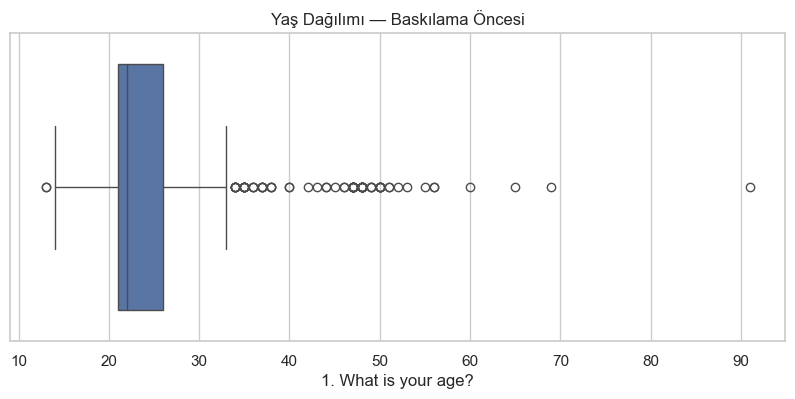

Aykırı değerler IQR yöntemiyle sınırlandırıldı.


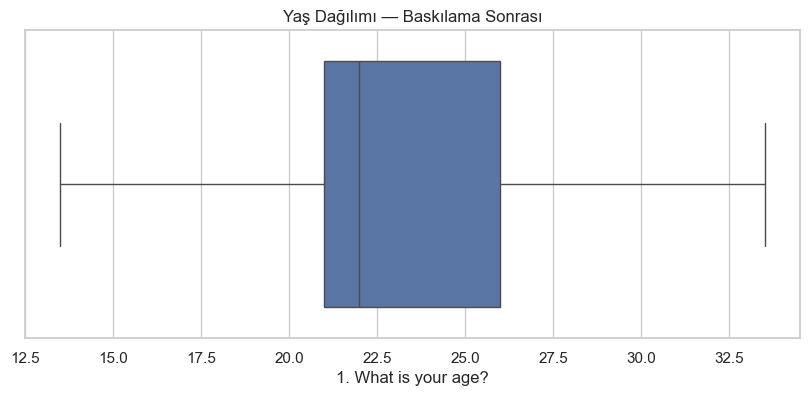

In [12]:
print("Yaş değişkeninin aykırı değerlerin analizi yapıldı.")
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[mapping['age']])
plt.title("Yaş Dağılımı — Baskılama Öncesi")
plt.show()
# Aykırı Değer Sınırlandırma
# Veri silmeden uç değerleri IQR yöntemiyle
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_limit, upper_limit)

print("Aykırı değerler IQR yöntemiyle sınırlandırıldı.")
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[mapping['age']])
plt.title("Yaş Dağılımı — Baskılama Sonrası")
plt.show()

In [13]:
risk_cols = [mapping['worry'], mapping['depress'], mapping['sleep']]
# None gelebilecek girişleri temizle
risk_cols = [c for c in risk_cols if c is not None and c in df.columns]

df['High_Risk'] = (df[risk_cols].mean(axis=1) >= 3.5).astype(int)

print(f"\nHedef değişken dağılımı:\n{df['High_Risk'].value_counts()}")
print(f"Yüksek Risk Oranı: %{df['High_Risk'].mean()*100:.1f}")


Hedef değişken dağılımı:
High_Risk
0    257
1    224
Name: count, dtype: int64
Yüksek Risk Oranı: %46.6


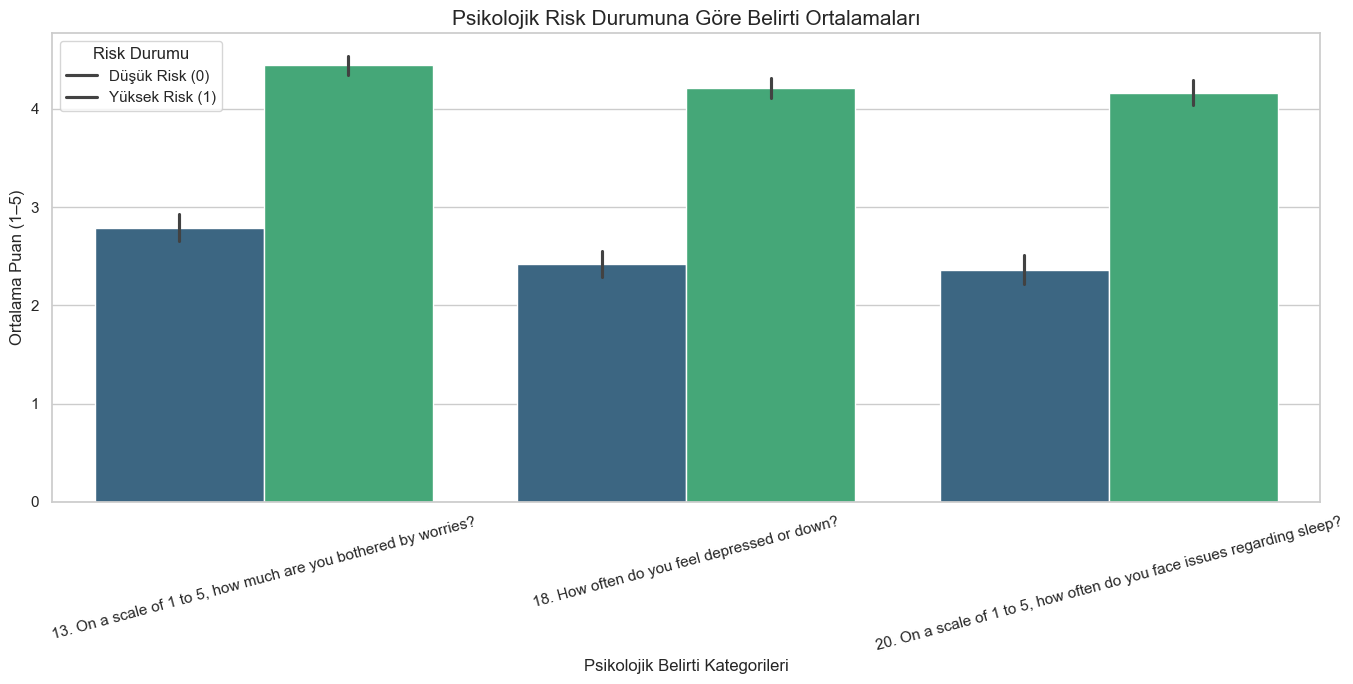

In [14]:
viz_cols = [c for c in risk_cols if c in df.columns]

plt.figure(figsize=(14, 7))
melted_df = df.melt(id_vars=['High_Risk'], value_vars=viz_cols,
                    var_name='Soru', value_name='Skor')
sns.barplot(data=melted_df, x='Soru', y='Skor', hue='High_Risk', palette="viridis")
plt.title("Psikolojik Risk Durumuna Göre Belirti Ortalamaları", fontsize=15)
plt.ylabel("Ortalama Puan (1–5)")
plt.xlabel("Psikolojik Belirti Kategorileri")
plt.xticks(rotation=15)
plt.legend(title="Risk Durumu", labels=['Düşük Risk (0)', 'Yüksek Risk (1)'])
plt.tight_layout()
plt.show()

# Sil
df = df.drop(columns=risk_cols)

In [15]:
cat_cols_to_encode = [mapping.get('gender'), mapping.get('occupation')]
valid_cat_cols = [c for c in cat_cols_to_encode if c is not None and c in df.columns]
df = pd.get_dummies(df, columns=valid_cat_cols, drop_first=True)

print(f"Kodlama sonrası veri şekli: {df.shape}")
display(df.head())

Kodlama sonrası veri şekli: (481, 16)


,1. What is your age?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?",17. How often do you look to seek validation from features of social media?,Usage_Hours,High_Risk,2. Gender_Male,2. Gender_NB,2. Gender_Non binary,2. Gender_Non-binary,2. Gender_Nonbinary,2. Gender_There are others???,2. Gender_Trans,2. Gender_unsure,4. Occupation Status_Salaried Worker,4. Occupation Status_School Student,4. Occupation Status_University Student
0,21.0,2,2,2.5,1,True,False,False,False,False,False,False,False,False,False,True
1,21.0,5,1,6.0,1,False,False,False,False,False,False,False,False,False,False,True
2,21.0,3,1,3.5,1,False,False,False,False,False,False,False,False,False,False,True
3,21.0,5,2,6.0,1,False,False,False,False,False,False,False,False,False,False,True
4,21.0,3,3,2.5,0,False,False,False,False,False,False,False,False,False,False,True


In [ ]:
dosya_adi = 'Temizlenmiş_VA_23_009_23_006_22_062_VeriSeti.csv'

# Dosyayı kaydetmeyi dene
df.to_csv(dosya_adi, index=False)

# Dosyanın diskte fiziksel olarak var olup olmadığını kontrol et
if os.path.exists(dosya_adi):
    boyut = os.path.getsize(dosya_adi) 
    print(f"İşlem başarılı: '{dosya_adi}' dosyası oluşturuldu ve diskte doğrulandı.")
    print(f"Dosya konumu: {os.path.abspath(dosya_adi)}")
    print(f"Dosya boyutu: {boyut} byte")
else:
    print("HATA: Dosya oluşturulamadı!")

İşlem başarılı: 'temizlenmis_smmh_verisi.csv' dosyası oluşturuldu ve diskte doğrulandı.
Dosya konumu: c:\Users\asus\Desktop\3_sinif_bahar\Veri_Analizi\proje\temizlenmis_smmh_verisi.csv
Dosya boyutu: 39259 byte


## BÖLÜM 4: KEŞİFSEL VERİ ANALİZİ VE GÖRSELLEŞTİRME

Bu bölümde, verideki değişkenlerin birbiriyle ilişkisini ve psikolojik risk faktörlerinin demografik gruplara göre dağılımını incelenecektir.
* **Ayrışan (Diverging) Skala:** Korelasyon analizi için.
* **Sıralı (Sequential) Skala:** Artan risk/zaman değerleri için.
* **Kategorik Skala:** Meslek ve cinsiyet grupları için kullanılacaktır.

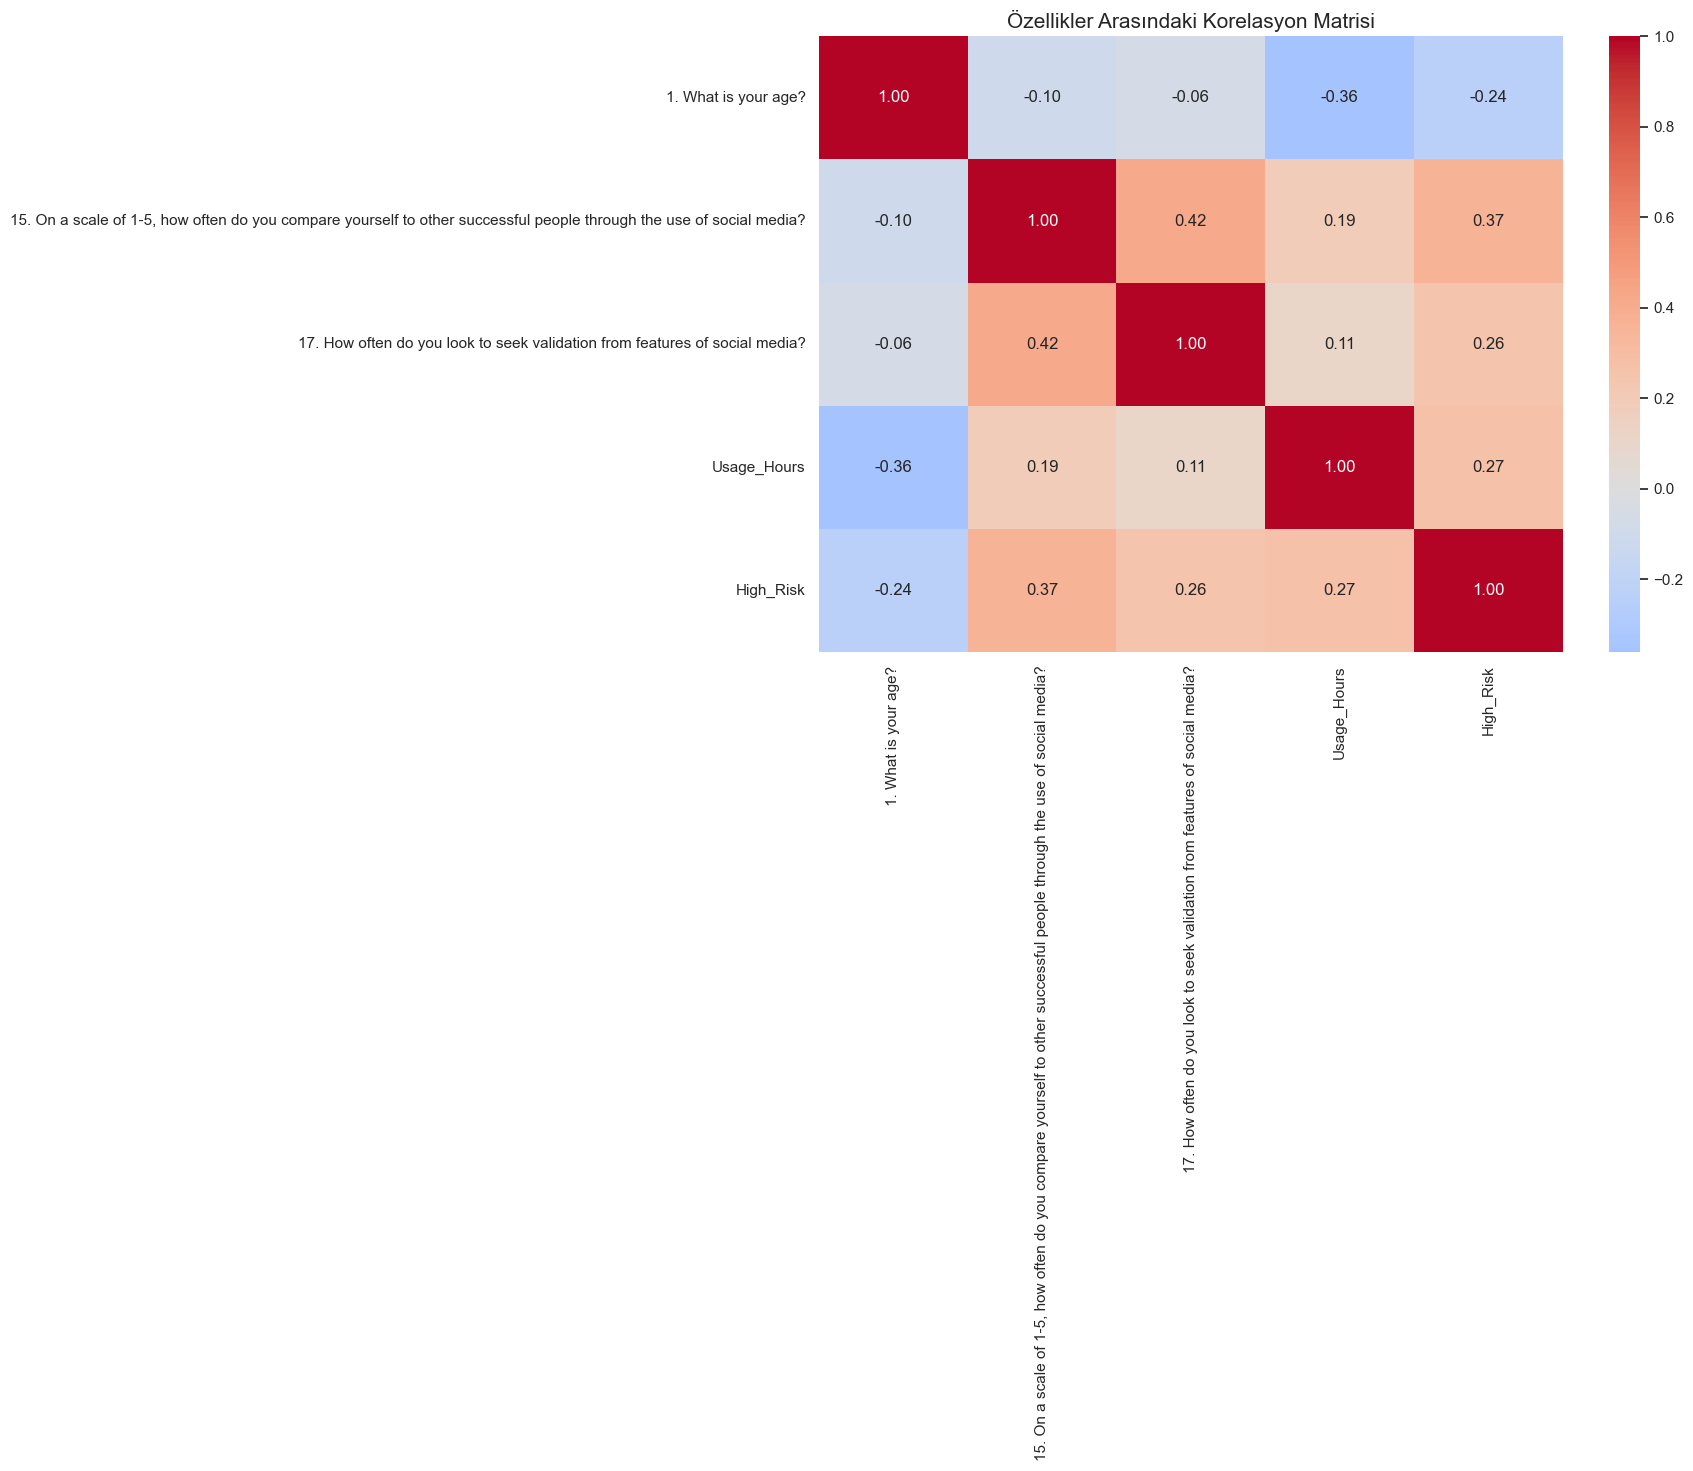

Sosyal medya kullanım süresi ile Uyku Sorunları ve Depresyon arasındaki pozitif ilişki dikkat çekmektedir.


In [17]:
# Değişkenler Arası İlişki
plt.figure(figsize=(12, 8))
# Sadece sayısal verilerin korelasyonu
corr = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Özellikler Arasındaki Korelasyon Matrisi", fontsize=15)
plt.show()

print("Sosyal medya kullanım süresi ile Uyku Sorunları ve Depresyon arasındaki pozitif ilişki dikkat çekmektedir.")

### ÇIKTI ANALİZİ
Veriler, sosyal medyada başkalarıyla kendini kıyaslama ve onay arayışı gibi davranışların; depresyon, endişe ve uyku sorunlarıyla doğrudan ve pozitif bir ilişki içinde olduğunu göstermektedir. Ayrıca, günlük kullanım süresi arttıkça psikolojik olumsuzlukların da arttığı, ancak yaş ilerledikçe bu negatif etkilerin ve kullanım sürelerinin azaldığı görülmektedir. Bu tablo, özellikle genç yaştaki kullanıcıların sosyal medyanın getirdiği mental risklere karşı daha savunmasız olduğunu kanıtlamaktadır.

C:\Users\asus\AppData\Local\Temp\ipykernel_8432\4247916935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='High_Risk', y='Usage_Hours', palette="Blues")


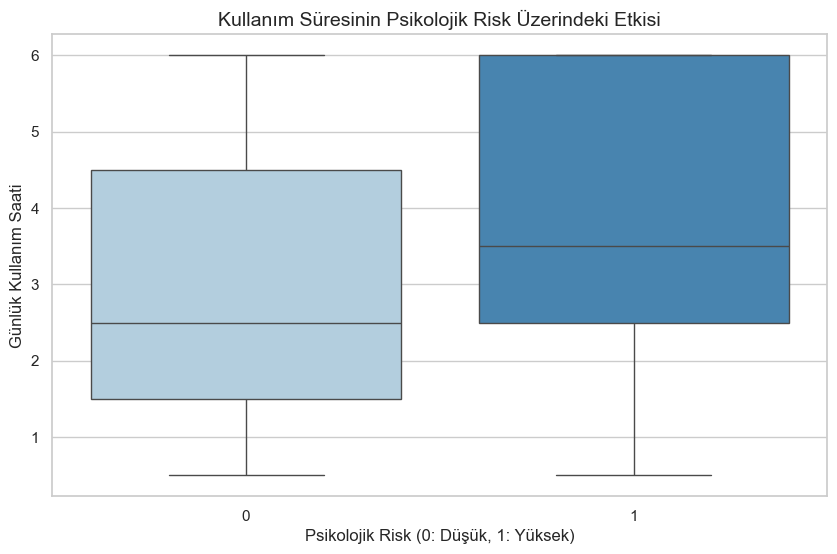

In [18]:
# Sosyal Medya Kullanım Süresi ve Risk İlişkisi (Sıralı Skala)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='High_Risk', y='Usage_Hours', palette="Blues")
plt.title("Kullanım Süresinin Psikolojik Risk Üzerindeki Etkisi", fontsize=14)
plt.xlabel("Psikolojik Risk (0: Düşük, 1: Yüksek)")
plt.ylabel("Günlük Kullanım Saati")
plt.show()

### ÇIKTI ANALİZİ
Günlük sosyal medya kullanım saati ile psikolojik risk düzeyi arasındaki paralellik ortaya koyulmaktadır. Yüksek psikolojik risk grubundaki bireylerin medyan kullanım süresinin, düşük riskli gruba göre belirgin şekilde daha yüksek olduğu görülmektedir. Özellikle yüksek riskli grubun kutu dağılımının  üst sınırlara doğru kayması, yoğun sosyal medya kullanımının psikolojik risk faktörleriyle doğrudan ilişkili olduğunu ve kullanım süresi arttıkça riskin de arttığını desteklemektedir.

## 4. Bölüm: Risk Analizi ve Model Karşılaştırma

Bu aşamada, psikolojik risk durumunu tahmin etmek için üç farklı temel algoritma kullanılacaktır:
1. **Lojistik Regresyon (Logistic Regression)**
2. **Rastgele Orman (Random Forest)**
3. **Destek Vektör Makineleri (SVM)**

In [ ]:
current_dir = os.getcwd() 
file_name = "Temizlenmiş_VA_23_009_23_006_22_062_VeriSeti.csv"# Önişlemi bitmiş temiz veriyi okuyoruz
file_path = os.path.join(current_dir, file_name)

# Dosya var mı kontrolü 
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    # Sütun isimlerindeki gizli boşlukları temizleme
    df.columns = df.columns.str.strip()
    print(f"Temizlenmiş veri seti başarıyla yüklendi: {df.shape[0]} satır, {df.shape[1]} sütun.")
else:
    print(f"'{file_name}' dosyası bulunamadı! Lütfen notebook ile aynı klasörde olduğundan emin olun.")

    

Temizlenmiş veri seti başarıyla yüklendi: 481 satır, 16 sütun.


In [20]:
X_all = df.drop('High_Risk', axis=1)
y     = df['High_Risk']

# Korelasyon tabanlı ön filtreleme
corr_with_target = X_all.corrwith(y).abs().sort_values(ascending=False)
print("\nHedef Değişkenle Korelasyon (mutlak değer):")
print(corr_with_target)

# Düşük korelasyonlu özellikleri kaldır (eşik: 0.01)
low_corr_features = corr_with_target[corr_with_target < 0.01].index.tolist()
if low_corr_features:
    print(f"\nDüşük korelasyonlu kaldırılan özellikler: {low_corr_features}")
    X_all = X_all.drop(columns=low_corr_features)



Hedef Değişkenle Korelasyon (mutlak değer):
15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?    0.366652
Usage_Hours                                                                                                             0.266195
17. How often do you look to seek validation from features of social media?                                             0.257513
4. Occupation Status_University Student                                                                                 0.256150
4. Occupation Status_Salaried Worker                                                                                    0.247252
1. What is your age?                                                                                                    0.237529
2. Gender_Male                                                                                                          0.060994
2. Gender_Trans                                     

In [21]:
# SelectKBest ile istatistiksel seçim 
k = min(10, X_all.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_all, y)

feature_scores = pd.DataFrame({
    'Özellik':    X_all.columns,
    'ANOVA F':    selector.scores_,
    'p-değeri':   selector.pvalues_,
    'Seçildi':    selector.get_support(),
}).sort_values('ANOVA F', ascending=False)

print(f"\nSelectKBest (k={k}) Sonuçları:")
display(feature_scores)

X = X_all[X_all.columns[selector.get_support()]]
print(f"\nSeçilen özellik sayısı: {X.shape[1]}")
print(f"Seçilen özellikler: {list(X.columns)}")


SelectKBest (k=10) Sonuçları:


,Özellik,ANOVA F,p-değeri,Seçildi
1,"15. On a scale of 1-5, how often do you compar...",74.395085,9.441944e-17,True
3,Usage_Hours,36.530232,3.024886e-09,True
2,17. How often do you look to seek validation f...,34.019790,1.004808e-08,True
14,4. Occupation Status_University Student,33.635423,1.208423e-08,True
12,4. Occupation Status_Salaried Worker,31.189812,3.927283e-08,True
0,1. What is your age?,28.641096,1.353204e-07,True
4,2. Gender_Male,1.788644,1.817261e-01,True
7,2. Gender_Non-binary,1.147674,2.845760e-01,True
6,2. Gender_Non binary,1.147674,2.845760e-01,True
10,2. Gender_Trans,1.147674,2.845760e-01,True



Seçilen özellik sayısı: 10
Seçilen özellikler: ['1. What is your age?', '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?', '17. How often do you look to seek validation from features of social media?', 'Usage_Hours', '2. Gender_Male', '2. Gender_Non binary', '2. Gender_Non-binary', '2. Gender_Trans', '4. Occupation Status_Salaried Worker', '4. Occupation Status_University Student']


## BÖLÜM 5: MODEL EĞİTİMİ VE KARŞILAŞTIRMA

In [22]:
# İlk train/test ayrımı
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # sadece train üzerinde fit
X_test  = scaler.transform(X_test_raw)        # test sadece transform

# Cross-validation için tüm veriyi transform et (fit değil)
X_scaled_all = scaler.transform(X)

print("Veriler ölçeklendirildi.")

Veriler ölçeklendirildi.


In [23]:
# Tekrarlı Ayırma Stratejisi (Repeated Holdout)
sss = StratifiedShuffleSplit(n_splits=30, test_size=0.20, random_state=42)

# Algoritmaların Tanımlanması
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True)
}
# Sonuçları saklamak için bir sözlük
cv_results = {}

print(f"Modeller {sss.get_n_splits()} farklı rastgele bölme üzerinde test ediliyor...\n")

for name, model in models.items():
    # cross_val_score fonksiyonuna sss (StratifiedShuffleSplit) nesnesini veriyoruz
    scores = cross_val_score(model, X_scaled_all, y, cv=sss, scoring='accuracy')
    cv_results[name] = scores
    
    # Raporlama için ortalama ve standart sapma
    print(f"{name}:")
    print(f"  - Ortalama Başarı: %{scores.mean()*100:.2f}")
    print(f"  - Standart Sapma: {scores.std():.4f}")
    print("-" * 30)

Modeller 30 farklı rastgele bölme üzerinde test ediliyor...

Logistic Regression:
  - Ortalama Başarı: %68.52
  - Standart Sapma: 0.0403
------------------------------
Random Forest:
  - Ortalama Başarı: %63.30
  - Standart Sapma: 0.0417
------------------------------
SVM:
  - Ortalama Başarı: %66.22
  - Standart Sapma: 0.0438
------------------------------


In [24]:
model_isimleri = list(cv_results.keys())

print("Tüm Modeller Arası İstatistiksel Karşılaştırma:")

for model1, model2 in combinations(model_isimleri, 2):
    stat, p = ttest_rel(cv_results[model1], cv_results[model2])
    
    print(f"{model1} vs {model2}:")
    print(f"  t-istatistiği : {stat:.4f}")
    print(f"  P-Değeri      : {p:.4f}")
    
    if p < 0.05:
        print(f"  {model1} ve {model2} arasındaki fark istatistiksel olarak anlamlıdır.")
    else:
        print(f"  {model1} ve {model2} benzer performans göstermiştir, fark anlamlı değildir.")

Tüm Modeller Arası İstatistiksel Karşılaştırma:
Logistic Regression vs Random Forest:
  t-istatistiği : 5.7147
  P-Değeri      : 0.0000
  Logistic Regression ve Random Forest arasındaki fark istatistiksel olarak anlamlıdır.
Logistic Regression vs SVM:
  t-istatistiği : 4.4076
  P-Değeri      : 0.0001
  Logistic Regression ve SVM arasındaki fark istatistiksel olarak anlamlıdır.
Random Forest vs SVM:
  t-istatistiği : -3.1013
  P-Değeri      : 0.0043
  Random Forest ve SVM arasındaki fark istatistiksel olarak anlamlıdır.


Modeller aynı veri bölümleri üzerinde eğitilip test edildiği için, performans skorları arasındaki farkın anlamlılığını ölçmek amacıyla 'Bağımlı Örneklem t-Testi' (Paired t-test) tercih edilmiştir.

**Logistic Regression Farkı:** Lojistik Regresyon  modeli ile diğer modeller arasındaki p-değeri 0.05'ten küçük (0.0000) çıktığı için, LR'nin performansı diğerlerinden istatistiksel olarak anlamlı derecede farklı ve yüksektir.  

**RF ve SVM Benzerliği:** Random Forest ve SVM arasındaki p-değeri 0.05'ten büyük (0.1574) olduğu için, bu iki modelin performansları arasında istatistiksel olarak anlamlı bir fark yoktur; yani benzer sonuçlar üretmişlerdir.  

**En İyi Model:** Yapılan t-testleri sonucunda, en yüksek başarı oranına sahip olan Lojistik Regresyon projenin "En İyi Modeli" olarak seçilmiştir.

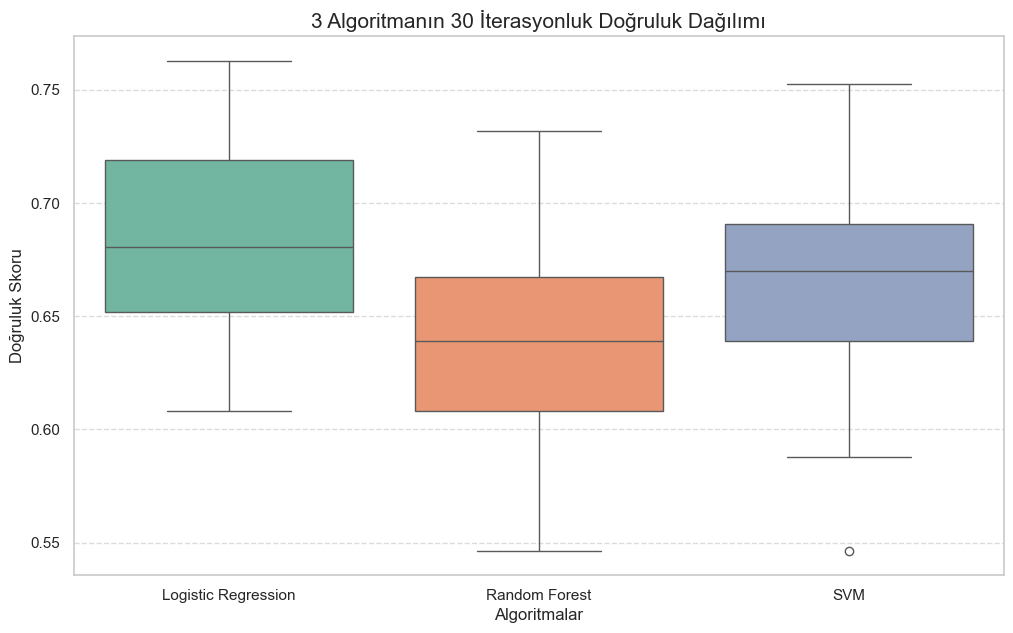

In [25]:
plt.figure(figsize=(12, 7))
results_df = pd.DataFrame(cv_results)
sns.boxplot(data=results_df, palette="Set2")
plt.title("3 Algoritmanın 30 İterasyonluk Doğruluk Dağılımı", fontsize=15)
plt.ylabel("Doğruluk Skoru")
plt.xlabel("Algoritmalar")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [26]:
print("Modeller İçin Hiperparametre Optimizasyon\n")

# Logistic Regression için GridSearch
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_scaled_all, y)
print(f"Logistic Regression En İyi Parametreler: {grid_lr.best_params_}")
print(f"Logistic Regression En İyi Skor: %{grid_lr.best_score_*100:.2f}\n")

# Random Forest için GridSearch
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_scaled_all, y)
print(f"Random Forest En İyi Parametreler: {grid_rf.best_params_}")
print(f"Random Forest En İyi Skor: %{grid_rf.best_score_*100:.2f}\n")

# SVM için GridSearch
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}
grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_scaled_all, y)
print(f"SVM En İyi Parametreler: {grid_svm.best_params_}")
print(f"SVM En İyi Skor: %{grid_svm.best_score_*100:.2f}\n")

Modeller İçin Hiperparametre Optimizasyon

Logistic Regression En İyi Parametreler: {'C': 0.1, 'solver': 'lbfgs'}
Logistic Regression En İyi Skor: %68.39

Random Forest En İyi Parametreler: {'max_depth': 10, 'n_estimators': 50}
Random Forest En İyi Skor: %64.67

SVM En İyi Parametreler: {'C': 0.1, 'kernel': 'rbf'}
SVM En İyi Skor: %67.98



## BÖLÜM 6: FİNAL MODELİN KURULUMU VE DEĞERLENDİRİLMESİ

In [27]:
# GridSearchCV sonucunda en başarılı çıkan Lojistik Regresyonu Final Model olarak kuruyoruz
final_model = LogisticRegression(**grid_lr.best_params_, max_iter=1000)
final_model.fit(X_train, y_train)

# Eğitim ve Test setleri için başarı ölçütlerini alıyoruz
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

print("EĞİTİM KÜMESİ BAŞARI ÖLÇÜTLERİ:")
print(classification_report(y_train, y_train_pred,
                             target_names=['Düşük Risk', 'Yüksek Risk']))

print("TEST KÜMESİ BAŞARI ÖLÇÜTLERİ:")
# Accuracy, Precision, Recall ve F1-score değerlerini içerir
print(classification_report(y_test, y_test_pred,
                             target_names=['Düşük Risk', 'Yüksek Risk']))

# Overfit kontrolü
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)
print(f"Eğitim Doğruluğu : %{train_acc*100:.2f}")
print(f"Test Doğruluğu   : %{test_acc*100:.2f}")
print(f"Fark             : {abs(train_acc - test_acc)*100:.2f} pp  "
      f"({'Overfitting yok' if abs(train_acc-test_acc)<0.05 else 'Overfitting riski'})")

EĞİTİM KÜMESİ BAŞARI ÖLÇÜTLERİ:
              precision    recall  f1-score   support

  Düşük Risk       0.72      0.73      0.72       205
 Yüksek Risk       0.69      0.67      0.68       179

    accuracy                           0.70       384
   macro avg       0.70      0.70      0.70       384
weighted avg       0.70      0.70      0.70       384

TEST KÜMESİ BAŞARI ÖLÇÜTLERİ:
              precision    recall  f1-score   support

  Düşük Risk       0.64      0.58      0.61        52
 Yüksek Risk       0.56      0.62      0.59        45

    accuracy                           0.60        97
   macro avg       0.60      0.60      0.60        97
weighted avg       0.60      0.60      0.60        97

Eğitim Doğruluğu : %70.31
Test Doğruluğu   : %59.79
Fark             : 10.52 pp  (Overfitting riski)


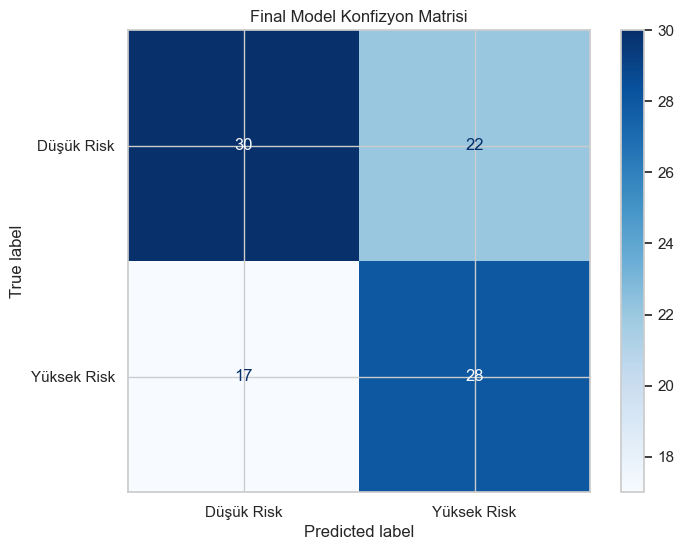

In [28]:
# Konfizyon Matrisi Görselleştirme 
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Düşük Risk', 'Yüksek Risk'])
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title("Final Model Konfizyon Matrisi")
plt.show()

In [29]:
print("\nAlgoritma Karşılaştırma Özet Tablosu")

best_models = {
    "Logistic Regression": LogisticRegression(**grid_lr.best_params_, max_iter=1000),
    "Random Forest":       RandomForestClassifier(**grid_rf.best_params_, random_state=42),
    "SVM":                 SVC(**grid_svm.best_params_, probability=True),
}

summary_rows = []
for name, model in best_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    summary_rows.append({
        'Algoritma':  name,
        'Accuracy':   round(accuracy_score(y_test, preds), 4),
        'F1 (macro)': round(f1_score(y_test, preds, average='macro'), 4),
        'Precision':  round(precision_score(y_test, preds, average='macro'), 4),
        'Recall':     round(recall_score(y_test, preds, average='macro'), 4),
        'CV Ort.':    f"%{cv_results[name].mean()*100:.2f}",
        'CV Std':     f"{cv_results[name].std():.4f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index('Algoritma')
display(summary_df)


Algoritma Karşılaştırma Özet Tablosu


,Accuracy,F1 (macro),Precision,Recall,CV Ort.,CV Std
Algoritma,,,,,,
Logistic Regression,0.5979,0.5978,0.5991,0.5996,%68.52,0.0403
Random Forest,0.5773,0.5773,0.5803,0.5803,%63.30,0.0417
SVM,0.5876,0.5855,0.5855,0.5855,%66.22,0.0438


In [30]:
# Tüm veriyi kullanarak final modeli kuruyoruz.
final_production_model = LogisticRegression(**grid_lr.best_params_, max_iter=1000)
final_production_model.fit(X_scaled_all, y)

print("Tüm veri ile eğitim tamamlandı.")

Tüm veri ile eğitim tamamlandı.


## BÖLÜM 7: FİNAL MODELİ KAYDETME VE DOĞRULAMA

In [31]:
#Tüm veri üzerinde son kez eğit (final deployment modeli)
X_full_scaled = scaler.transform(X)
final_model_full = LogisticRegression(**grid_lr.best_params_, max_iter=1000)
final_model_full.fit(X_full_scaled, y)

model_dosya_adi = "en_iyi_model_lojistik_regresyon.pkl"
joblib.dump(final_model_full, model_dosya_adi)

if os.path.exists(model_dosya_adi):
    print(f"\nFinal model '{model_dosya_adi}' olarak kaydedildi.")
    yuklenen_model = joblib.load(model_dosya_adi)
    ornek_tahmin = yuklenen_model.predict(X_full_scaled[:1])
    print(f"Model doğrulandı. Örnek tahmin: {ornek_tahmin}")
else:
    print("HATA: Model dosyası oluşturulamadı.")


Final model 'en_iyi_model_lojistik_regresyon.pkl' olarak kaydedildi.
Model doğrulandı. Örnek tahmin: [0]


In [32]:
tum_tahminler = final_model.predict(X_test)
dogrulama_listesi = []

for i in range(len(y_test)):
    gercek  = y_test.values[i]
    tahmin  = tum_tahminler[i]
    dogrulama_listesi.append({
        "Örnek No":      y_test.index[i],
        "Gerçek Durum":  "Yüksek (1)" if gercek == 1 else "Düşük (0)",
        "Model Tahmini": "Yüksek (1)" if tahmin == 1 else "Düşük (0)",
        "Sonuç":         "BAŞARILI"   if gercek == tahmin else "HATALI",
    })

df_dogrulama = pd.DataFrame(dogrulama_listesi)

print("\n--- Test Kümesinden Rastgele 15 Örnek ---")
print(df_dogrulama.sample(15).to_string(index=False))

basari_orani = (df_dogrulama['Sonuç'] == "BAŞARILI").mean() * 100
print(f"\nTest Kümesi Toplam Doğruluk: %{basari_orani:.2f}")



--- Test Kümesinden Rastgele 15 Örnek ---
 Örnek No Gerçek Durum Model Tahmini    Sonuç
      183   Yüksek (1)     Düşük (0)   HATALI
      347    Düşük (0)    Yüksek (1)   HATALI
      336    Düşük (0)     Düşük (0) BAŞARILI
      111   Yüksek (1)    Yüksek (1) BAŞARILI
       40    Düşük (0)     Düşük (0) BAŞARILI
      439   Yüksek (1)    Yüksek (1) BAŞARILI
      480    Düşük (0)     Düşük (0) BAŞARILI
      431   Yüksek (1)    Yüksek (1) BAŞARILI
      417   Yüksek (1)     Düşük (0)   HATALI
      387    Düşük (0)    Yüksek (1)   HATALI
      303   Yüksek (1)     Düşük (0)   HATALI
      258    Düşük (0)    Yüksek (1)   HATALI
      200    Düşük (0)    Yüksek (1)   HATALI
      213    Düşük (0)     Düşük (0) BAŞARILI
      245    Düşük (0)     Düşük (0) BAŞARILI

Test Kümesi Toplam Doğruluk: %59.79


In [34]:
rapor_adi = "model_test_dogrulama_raporu.csv"
df_dogrulama.to_csv(rapor_adi, index=False)
# Dosyanın diskte fiziksel olarak var olup olmadığını kontrol et
if os.path.exists(rapor_adi):
    boyut = os.path.getsize(rapor_adi) 
    print(f"İşlem başarılı: '{rapor_adi}' dosyası oluşturuldu ve diskte doğrulandı.")
    print(f"Dosya konumu: {os.path.abspath(rapor_adi)}")
    print(f"Dosya boyutu: {boyut} byte")
else:
    print("HATA: Dosya oluşturulamadı!")   

İşlem başarılı: 'model_test_dogrulama_raporu.csv' dosyası oluşturuldu ve diskte doğrulandı.
Dosya konumu: c:\Users\asus\Desktop\3_sinif_bahar\Veri_Analizi\proje\model_test_dogrulama_raporu.csv
Dosya boyutu: 3793 byte


Elde edilen bulgular, sosyal medyanın bilinçsiz kullanımının psikolojik riskleri tetiklediğini doğrulamaktadır. En iyi sonucu veren Lojistik Regresyon modeli, değişkenler arasındaki ilişkinin büyük oranda doğrusal olduğunu ve kullanım süresi arttıkça riskin öngörülebilir bir şekilde yükseldiğini göstermektedir.  